<a href="https://colab.research.google.com/github/Oruntu-Tanima-Proje/otProje/blob/main/notebooks/01_veri_hazirlik.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
print("TensorFlow versiyonu:", tf.__version__)
print("GPU sayısı:", len(tf.config.list_physical_devices('GPU')))
print("GPU bilgisi:", tf.config.list_physical_devices('GPU'))

TensorFlow versiyonu: 2.20.0
GPU sayısı: 1
GPU bilgisi: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Kaggle kütüphanesini yükle
!pip install -q kaggle

# kaggle.json dosyasını yükle
from google.colab import files
print("Lütfen masaüstünüzdeki kaggle.json dosyasını seçin:")
uploaded = files.upload()

Lütfen masaüstünüzdeki kaggle.json dosyasını seçin:


Saving kaggle.json to kaggle.json


In [ ]:
# Kaggle config dizinini hazırla
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Test et - PlantVillage veri setlerini ara
!kaggle datasets list -s plantvillage --max-size 100

print("\n✅ Kaggle API hazır!")

ref                                  title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
devharis/plantvillage-yolo-modified  PlantVillage Object Detection YOLO Dataset (Modifi   861229997  2026-02-24 09:28:49.077000             25          2  0.5625           
mayank0700/potato-terox              potato-terox                                                 0  2024-04-07 04:13:47.650000              0          0  0.25             

✅ Kaggle API hazır!


In [ ]:
# Veri setini indir (~3 GB, 3-7 dakika sürer)
print("Veri seti indiriliyor, lütfen bekleyin...\n")
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

print("\n✅ İndirme tamamlandı!")
print("\nDosya boyutu:")
!ls -lh new-plant-diseases-dataset.zip

Veri seti indiriliyor, lütfen bekleyin...

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [00:18<00:00, 157MB/s]


✅ İndirme tamamlandı!

Dosya boyutu:
-rw-r--r-- 1 root root 2.7G Oct 12  2019 new-plant-diseases-dataset.zip


In [ ]:
# Zip dosyasını çıkar (sessiz mod)
print("Zip dosyası çıkarılıyor, bu 2-3 dakika sürebilir...\n")
!unzip -q new-plant-diseases-dataset.zip -d plant_data/

# Yer açmak için zip'i sil
!rm new-plant-diseases-dataset.zip

print("\n✅ Çıkarma tamamlandı!")
print("\nAna klasör içeriği:")
!ls plant_data/

Zip dosyası çıkarılıyor, bu 2-3 dakika sürebilir...


✅ Çıkarma tamamlandı!

Ana klasör içeriği:
'new plant diseases dataset(augmented)'   test
'New Plant Diseases Dataset(Augmented)'


In [ ]:
import os

data_dir = "plant_data"

print("📁 Veri seti klasör yapısı (3 seviye derinlik):\n")
for root, dirs, files in os.walk(data_dir):
    level = root.replace(data_dir, '').count(os.sep)
    if level <= 3:
        indent = '  ' * level
        folder_name = os.path.basename(root) if root != data_dir else "plant_data"
        # Sadece klasörleri göster, çok dosya varsa sadece sayıyı yaz
        file_count = len([f for f in files if not f.startswith('.')])
        if file_count > 0 and level >= 3:
            print(f"{indent}📁 {folder_name}/ ({file_count} dosya)")
        else:
            print(f"{indent}📁 {folder_name}/")

📁 Veri seti klasör yapısı (3 seviye derinlik):

📁 plant_data/
  📁 test/
    📁 test/
  📁 New Plant Diseases Dataset(Augmented)/
    📁 New Plant Diseases Dataset(Augmented)/
      📁 train/
      📁 valid/
  📁 new plant diseases dataset(augmented)/
    📁 New Plant Diseases Dataset(Augmented)/
      📁 train/
      📁 valid/


In [ ]:
import os

# İki farklı yolu kontrol et
yol_1 = "plant_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
yol_2 = "plant_data/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train"
test_yolu = "plant_data/test/test"

print("=" * 60)
print("YOL 1 (Büyük harfli):")
print(yol_1)
if os.path.exists(yol_1):
    classes_1 = sorted(os.listdir(yol_1))
    print(f"✓ Var | Sınıf sayısı: {len(classes_1)}")
    print(f"İlk 3 sınıf: {classes_1[:3]}")
else:
    print("✗ Yok")

print("\n" + "=" * 60)
print("YOL 2 (Küçük harfli):")
print(yol_2)
if os.path.exists(yol_2):
    classes_2 = sorted(os.listdir(yol_2))
    print(f"✓ Var | Sınıf sayısı: {len(classes_2)}")
    print(f"İlk 3 sınıf: {classes_2[:3]}")
else:
    print("✗ Yok")

print("\n" + "=" * 60)
print("TEST KLASÖRÜ:")
print(test_yolu)
if os.path.exists(test_yolu):
    test_items = os.listdir(test_yolu)
    print(f"✓ Var | İçerik sayısı: {len(test_items)}")
    print(f"İlk 5 dosya/klasör: {test_items[:5]}")
else:
    print("✗ Yok")

print("\n" + "=" * 60)
print("Disk kullanımı:")
!df -h /content

YOL 1 (Büyük harfli):
plant_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
✓ Var | Sınıf sayısı: 38
İlk 3 sınıf: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust']

YOL 2 (Küçük harfli):
plant_data/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train
✓ Var | Sınıf sayısı: 38
İlk 3 sınıf: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust']

TEST KLASÖRÜ:
plant_data/test/test
✓ Var | İçerik sayısı: 33
İlk 5 dosya/klasör: ['TomatoEarlyBlight2.JPG', 'PotatoEarlyBlight4.JPG', 'TomatoEarlyBlight5.JPG', 'AppleScab2.JPG', 'AppleScab3.JPG']

Disk kullanımı:
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   47G   67G  41% /


In [ ]:
import shutil
import os

# Küçük harfli kopyayı sil (Yol 2)
duplicate_path = "plant_data/new plant diseases dataset(augmented)"

if os.path.exists(duplicate_path):
    print("Çift kopya siliniyor (küçük harfli klasör)...")
    shutil.rmtree(duplicate_path)
    print("✅ Silindi")
else:
    print("Zaten yok")

# Faydasız test klasörünü de sil (etiketli değil)
test_useless = "plant_data/test"
if os.path.exists(test_useless):
    print("\nFaydasız test klasörü siliniyor (etiketsiz görüntüler)...")
    shutil.rmtree(test_useless)
    print("✅ Silindi")

# Disk durumunu göster
print("\nDisk durumu:")
!df -h /content | head -2


Çift kopya siliniyor (küçük harfli klasör)...
✅ Silindi

Faydasız test klasörü siliniyor (etiketsiz görüntüler)...
✅ Silindi

Disk durumu:
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   45G   69G  40% /


In [ ]:
import os
import shutil

# Orijinal yollar
original_train = "plant_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
original_valid = "plant_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

# Hedef yollar (sadece domates için)
tomato_dir = "tomato_data"
tomato_train = f"{tomato_dir}/train"
tomato_valid = f"{tomato_dir}/valid"

# Domates sınıflarını bul
all_classes = sorted(os.listdir(original_train))
tomato_classes = [c for c in all_classes if c.startswith("Tomato")]

print(f"Toplam sınıf: {len(all_classes)} | Domates sınıfları: {len(tomato_classes)}\n")
print("🍅 Domates sınıfları:")
for i, cls in enumerate(tomato_classes, 1):
    short_name = cls.replace("Tomato___", "").replace("_", " ")
    print(f"  {i:2}. {short_name}")


Toplam sınıf: 38 | Domates sınıfları: 10

🍅 Domates sınıfları:
   1. Bacterial spot
   2. Early blight
   3. Late blight
   4. Leaf Mold
   5. Septoria leaf spot
   6. Spider mites Two-spotted spider mite
   7. Target Spot
   8. Tomato Yellow Leaf Curl Virus
   9. Tomato mosaic virus
  10. healthy


In [ ]:
# Hedef klasörleri oluştur
os.makedirs(tomato_train, exist_ok=True)
os.makedirs(tomato_valid, exist_ok=True)

# Train domates klasörlerini taşı (kopyalamak yerine taşıyoruz, yer kazanmak için)
print("Train domates klasörleri taşınıyor...\n")
for cls in tomato_classes:
    src = os.path.join(original_train, cls)
    dst = os.path.join(tomato_train, cls)
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.move(src, dst)
    count = len(os.listdir(dst)) if os.path.exists(dst) else 0
    print(f"  ✓ {cls}: {count} görüntü")

print("\nValid domates klasörleri taşınıyor...\n")
for cls in tomato_classes:
    src = os.path.join(original_valid, cls)
    dst = os.path.join(tomato_valid, cls)
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.move(src, dst)
    count = len(os.listdir(dst)) if os.path.exists(dst) else 0
    print(f"  ✓ {cls}: {count} görüntü")

print("\n✅ Domates klasörleri ayıklandı!")


Train domates klasörleri taşınıyor...

  ✓ Tomato___Bacterial_spot: 1702 görüntü
  ✓ Tomato___Early_blight: 1920 görüntü
  ✓ Tomato___Late_blight: 1851 görüntü
  ✓ Tomato___Leaf_Mold: 1882 görüntü
  ✓ Tomato___Septoria_leaf_spot: 1745 görüntü
  ✓ Tomato___Spider_mites Two-spotted_spider_mite: 1741 görüntü
  ✓ Tomato___Target_Spot: 1827 görüntü
  ✓ Tomato___Tomato_Yellow_Leaf_Curl_Virus: 1961 görüntü
  ✓ Tomato___Tomato_mosaic_virus: 1790 görüntü
  ✓ Tomato___healthy: 1926 görüntü

Valid domates klasörleri taşınıyor...

  ✓ Tomato___Bacterial_spot: 425 görüntü
  ✓ Tomato___Early_blight: 480 görüntü
  ✓ Tomato___Late_blight: 463 görüntü
  ✓ Tomato___Leaf_Mold: 470 görüntü
  ✓ Tomato___Septoria_leaf_spot: 436 görüntü
  ✓ Tomato___Spider_mites Two-spotted_spider_mite: 435 görüntü
  ✓ Tomato___Target_Spot: 457 görüntü
  ✓ Tomato___Tomato_Yellow_Leaf_Curl_Virus: 490 görüntü
  ✓ Tomato___Tomato_mosaic_virus: 448 görüntü
  ✓ Tomato___healthy: 481 görüntü

✅ Domates klasörleri ayıklandı!


In [ ]:
# Diğer 28 sınıfı içeren orijinal klasörü sil
original_root = "plant_data"
if os.path.exists(original_root):
    print("Orijinal veri seti siliniyor (artık ihtiyacımız yok)...")
    shutil.rmtree(original_root)
    print("✅ Silindi")

# Disk durumu
print("\nDisk durumu:")
!df -h /content | head -2

# Mevcut klasör yapısı
print("\n📁 Şu anki yapı:")
for root, dirs, files in os.walk("tomato_data"):
    level = root.replace("tomato_data", '').count(os.sep)
    if level <= 1:
        indent = '  ' * level
        folder = os.path.basename(root) if root != "tomato_data" else "tomato_data"
        print(f"{indent}📁 {folder}/")


Disk durumu:
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   44G   70G  39% /

📁 Şu anki yapı:
📁 tomato_data/
  📁 train/
  📁 valid/


In [ ]:
import os
import shutil
import random

random.seed(42)  # Tekrarlanabilirlik için sabit

# Yollar
tomato_dir = "tomato_data"
tomato_valid = f"{tomato_dir}/valid"
tomato_test = f"{tomato_dir}/test"

# Test klasörünü oluştur
os.makedirs(tomato_test, exist_ok=True)

# Valid klasöründeki sınıfları al
classes = sorted(os.listdir(tomato_valid))

print("Valid → Valid + Test ayrımı yapılıyor (50/50)...\n")
print(f"{'Sınıf':<55} {'Valid':>8} {'Test':>8}")
print("-" * 75)

for cls in classes:
    valid_class_dir = os.path.join(tomato_valid, cls)
    test_class_dir = os.path.join(tomato_test, cls)
    os.makedirs(test_class_dir, exist_ok=True)

    # Valid'deki tüm görüntüleri al, karıştır
    images = os.listdir(valid_class_dir)
    random.shuffle(images)

    # %50'sini test'e taşı
    test_count = len(images) // 2
    for img in images[:test_count]:
        src = os.path.join(valid_class_dir, img)
        dst = os.path.join(test_class_dir, img)
        shutil.move(src, dst)

    valid_after = len(os.listdir(valid_class_dir))
    test_after = len(os.listdir(test_class_dir))
    short_name = cls.replace("Tomato___", "").replace("_", " ")
    print(f"{short_name:<55} {valid_after:>8} {test_after:>8}")

print("\n✅ Valid/Test ayrımı tamamlandı!")

Valid → Valid + Test ayrımı yapılıyor (50/50)...

Sınıf                                                      Valid     Test
---------------------------------------------------------------------------
Bacterial spot                                               213      212
Early blight                                                 240      240
Late blight                                                  232      231
Leaf Mold                                                    235      235
Septoria leaf spot                                           218      218
Spider mites Two-spotted spider mite                         218      217
Target Spot                                                  229      228
Tomato Yellow Leaf Curl Virus                                245      245
Tomato mosaic virus                                          224      224
healthy                                                      241      240

✅ Valid/Test ayrımı tamamlandı!


In [ ]:
import os

print("=" * 70)
print("🍅 DOMATES VERİ SETİ - FİNAL ÖZET")
print("=" * 70)

splits = {
    "Train": "tomato_data/train",
    "Valid": "tomato_data/valid",
    "Test":  "tomato_data/test"
}

grand_total = 0
for split_name, split_dir in splits.items():
    print(f"\n📁 {split_name}")
    print("-" * 70)
    classes = sorted(os.listdir(split_dir))
    split_total = 0

    for cls in classes:
        class_dir = os.path.join(split_dir, cls)
        count = len(os.listdir(class_dir))
        split_total += count
        short_name = cls.replace("Tomato___", "").replace("_", " ")
        print(f"  {short_name:<55} {count:>5} görüntü")

    print(f"  {'─' * 60}")
    print(f"  {'TOPLAM':<55} {split_total:>5} görüntü")
    grand_total += split_total

print("\n" + "=" * 70)
print(f"🎯 GENEL TOPLAM: {grand_total} görüntü, 10 sınıf")
print("=" * 70)

# Disk durumu
print("\nDisk kullanımı:")
!df -h /content | head -2

🍅 DOMATES VERİ SETİ - FİNAL ÖZET

📁 Train
----------------------------------------------------------------------
  Bacterial spot                                           1702 görüntü
  Early blight                                             1920 görüntü
  Late blight                                              1851 görüntü
  Leaf Mold                                                1882 görüntü
  Septoria leaf spot                                       1745 görüntü
  Spider mites Two-spotted spider mite                     1741 görüntü
  Target Spot                                              1827 görüntü
  Tomato Yellow Leaf Curl Virus                            1961 görüntü
  Tomato mosaic virus                                      1790 görüntü
  healthy                                                  1926 görüntü
  ────────────────────────────────────────────────────────────
  TOPLAM                                                  18345 görüntü

📁 Valid
-----------------------

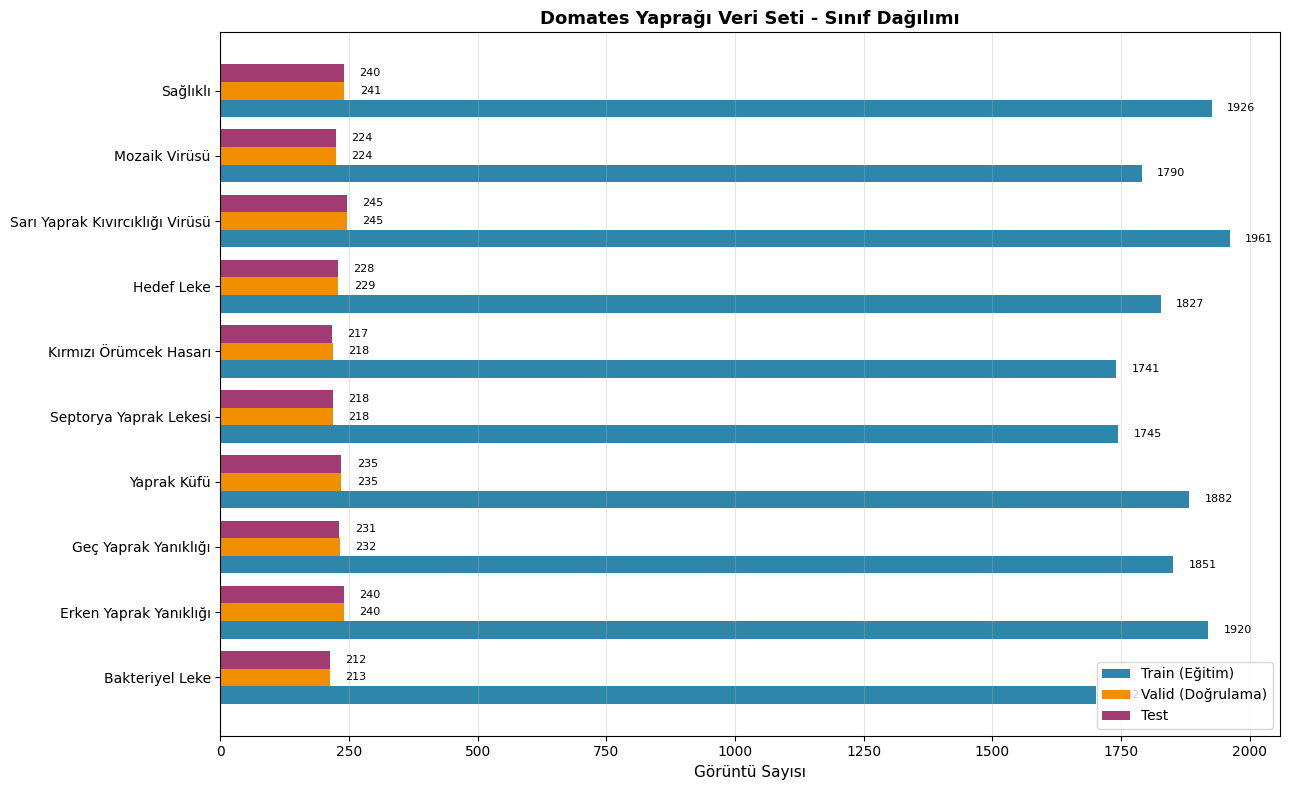


✅ Grafik kaydedildi: sinif_dagilimi.png
   Bu görseli raporuna ekleyebilirsin!


In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np

# Türkçe sınıf isimleri sözlüğü (raporda Türkçe görünsün)
class_names_tr = {
    "Tomato___Bacterial_spot": "Bakteriyel Leke",
    "Tomato___Early_blight": "Erken Yaprak Yanıklığı",
    "Tomato___Late_blight": "Geç Yaprak Yanıklığı",
    "Tomato___Leaf_Mold": "Yaprak Küfü",
    "Tomato___Septoria_leaf_spot": "Septorya Yaprak Lekesi",
    "Tomato___Spider_mites Two-spotted_spider_mite": "Kırmızı Örümcek Hasarı",
    "Tomato___Target_Spot": "Hedef Leke",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus": "Sarı Yaprak Kıvırcıklığı Virüsü",
    "Tomato___Tomato_mosaic_virus": "Mozaik Virüsü",
    "Tomato___healthy": "Sağlıklı"
}

# Yollar
train_dir = "tomato_data/train"
valid_dir = "tomato_data/valid"
test_dir = "tomato_data/test"

# Her sınıf için sayıları topla
classes = sorted(os.listdir(train_dir))
train_counts = []
valid_counts = []
test_counts = []

for cls in classes:
    train_counts.append(len(os.listdir(os.path.join(train_dir, cls))))
    valid_counts.append(len(os.listdir(os.path.join(valid_dir, cls))))
    test_counts.append(len(os.listdir(os.path.join(test_dir, cls))))

# Türkçe etiketler
labels_tr = [class_names_tr[c] for c in classes]

# Grafik çiz - Yatay bar chart (3 set bir arada)
fig, ax = plt.subplots(figsize=(13, 8))

y_pos = np.arange(len(classes))
height = 0.27

ax.barh(y_pos - height, train_counts, height, label='Train (Eğitim)', color='#2E86AB')
ax.barh(y_pos,          valid_counts, height, label='Valid (Doğrulama)', color='#F18F01')
ax.barh(y_pos + height, test_counts,  height, label='Test',  color='#A23B72')

ax.set_yticks(y_pos)
ax.set_yticklabels(labels_tr, fontsize=10)
ax.set_xlabel('Görüntü Sayısı', fontsize=11)
ax.set_title('Domates Yaprağı Veri Seti - Sınıf Dağılımı', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

# Sayıları bar uçlarına yaz
for i, (t, v, te) in enumerate(zip(train_counts, valid_counts, test_counts)):
    ax.text(t + 30, i - height, str(t), va='center', fontsize=8)
    ax.text(v + 30, i,          str(v), va='center', fontsize=8)
    ax.text(te + 30, i + height, str(te), va='center', fontsize=8)

plt.tight_layout()
plt.savefig('sinif_dagilimi.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Grafik kaydedildi: sinif_dagilimi.png")
print("   Bu görseli raporuna ekleyebilirsin!")

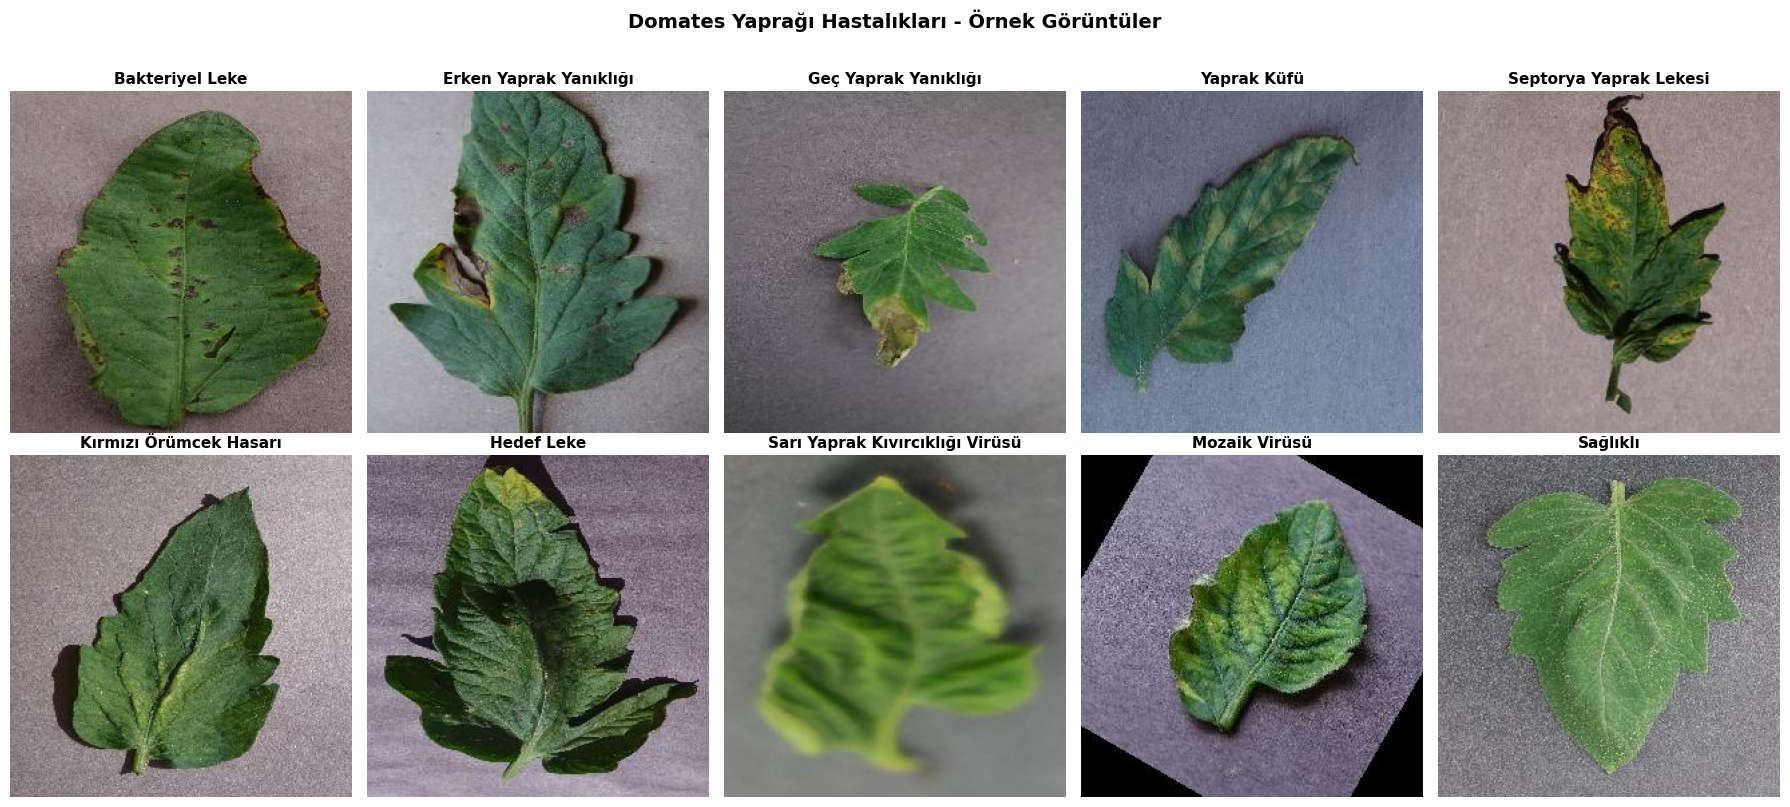


✅ Örnek görüntüler kaydedildi: ornek_goruntuler.png


In [ ]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

random.seed(42)

# 10 sınıfın her birinden 1 örnek göster
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, cls in enumerate(classes):
    class_path = os.path.join(train_dir, cls)
    sample_image = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, sample_image)
    img = Image.open(img_path)

    axes[i].imshow(img)
    axes[i].set_title(class_names_tr[cls], fontsize=11, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Domates Yaprağı Hastalıkları - Örnek Görüntüler',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ornek_goruntuler.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Örnek görüntüler kaydedildi: ornek_goruntuler.png")

In [ ]:
from PIL import Image
import random

# Rastgele 200 görüntünün boyutlarını kontrol et
sizes = []
for _ in range(200):
    rand_class = random.choice(classes)
    class_path = os.path.join(train_dir, rand_class)
    rand_img = random.choice(os.listdir(class_path))
    img = Image.open(os.path.join(class_path, rand_img))
    sizes.append(img.size)

# Benzersiz boyutları bul
from collections import Counter
size_counts = Counter(sizes)

print("📏 Görüntü Boyut Analizi (200 örneklem üzerinden)\n")
print(f"{'Boyut':<15} {'Sayı':>6}  {'Yüzde':>7}")
print("-" * 35)
for size, count in size_counts.most_common():
    pct = count / 200 * 100
    print(f"{str(size):<15} {count:>6}  {pct:>6.1f}%")

print(f"\n✅ Benzersiz boyut sayısı: {len(size_counts)}")
if len(size_counts) == 1:
    print("   Tüm görüntüler aynı boyutta — uniformluk var!")

📏 Görüntü Boyut Analizi (200 örneklem üzerinden)

Boyut             Sayı    Yüzde
-----------------------------------
(256, 256)         200   100.0%

✅ Benzersiz boyut sayısı: 1
   Tüm görüntüler aynı boyutta — uniformluk var!


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Sabit ayarlar
IMG_SIZE = 224          # MobileNetV2 standart girişi
BATCH_SIZE = 32         # Bir seferde işlenecek görüntü sayısı
NUM_CLASSES = 10        # Domates sınıf sayısı

# Yollar
train_dir = "tomato_data/train"
valid_dir = "tomato_data/valid"
test_dir = "tomato_data/test"

# EĞİTİM için: Hem normalize hem augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,                    # 0-255 → 0-1 arası
    rotation_range=20,                 # ±20 derece döndürme
    width_shift_range=0.1,             # Yatay kaydırma
    height_shift_range=0.1,            # Dikey kaydırma
    horizontal_flip=True,              # Yatay çevirme
    zoom_range=0.1,                    # Yakınlaştırma
    fill_mode='nearest'
)

# VALID ve TEST için: SADECE normalize (augmentation YOK!)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Veri yükleyicileri oluştur
print("Train generator hazırlanıyor...")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

print("\nValid generator hazırlanıyor...")
valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # Validation'da karıştırma!
)

print("\nTest generator hazırlanıyor...")
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # Test'te karıştırma!
)

# Sınıf indekslerini kontrol et
print("\n📋 Sınıf İndeksleri:")
for cls, idx in train_generator.class_indices.items():
    short = cls.replace("Tomato___", "").replace("_", " ")
    print(f"  {idx}: {short}")

print(f"\n✅ Generator'lar hazır!")
print(f"   Train: {train_generator.samples} görüntü, {len(train_generator)} batch")
print(f"   Valid: {valid_generator.samples} görüntü, {len(valid_generator)} batch")
print(f"   Test:  {test_generator.samples} görüntü, {len(test_generator)} batch")

Train generator hazırlanıyor...
Found 18345 images belonging to 10 classes.

Valid generator hazırlanıyor...
Found 2295 images belonging to 10 classes.

Test generator hazırlanıyor...
Found 2290 images belonging to 10 classes.

📋 Sınıf İndeksleri:
  0: Bacterial spot
  1: Early blight
  2: Late blight
  3: Leaf Mold
  4: Septoria leaf spot
  5: Spider mites Two-spotted spider mite
  6: Target Spot
  7: Tomato Yellow Leaf Curl Virus
  8: Tomato mosaic virus
  9: healthy

✅ Generator'lar hazır!
   Train: 18345 görüntü, 574 batch
   Valid: 2295 görüntü, 72 batch
   Test:  2290 görüntü, 72 batch


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

# 1. Hazır MobileNetV2'yi yükle (ImageNet ağırlıklarıyla)
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,           # Son katmanı (1000 sınıf) ATMAK için
    weights='imagenet'           # Önceden eğitilmiş ağırlıklar
)

# 2. Base modeli DONDUR (şimdilik eğitilmesin)
base_model.trainable = False

# 3. Üstüne kendi katmanlarımızı ekle
x = base_model.output
x = GlobalAveragePooling2D()(x)              # 7x7x1280 → 1280
x = Dropout(0.3)(x)                          # Overfitting'i azalt
x = Dense(128, activation='relu')(x)         # Ara katman
x = Dropout(0.3)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)  # 10 sınıf çıkışı

# 4. Modeli oluştur
model = Model(inputs=base_model.input, outputs=predictions)

# 5. Compile et (eğitime hazırla)
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model özeti
print(f"✅ MobileNetV2 modeli kuruldu!\n")
print(f"📊 Model İstatistikleri:")
print(f"   Toplam parametre: {model.count_params():,}")

trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"   Eğitilebilir: {trainable_params:,}")
print(f"   Donmuş (frozen): {model.count_params() - trainable_params:,}")
print(f"\n🎯 Sınıf sayısı: {NUM_CLASSES}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ MobileNetV2 modeli kuruldu!

📊 Model İstatistikleri:
   Toplam parametre: 2,423,242
   Eğitilebilir: 165,258
   Donmuş (frozen): 2,257,984

🎯 Sınıf sayısı: 10


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import time

# Modeli kaydetmek için klasör
import os
os.makedirs("models", exist_ok=True)

# Callback'ler (eğitim sırasında devreye girecek yardımcılar)
callbacks_phase1 = [
    # En iyi modeli kaydet
    ModelCheckpoint(
        'models/mobilenetv2_phase1.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    # 5 epoch boyunca iyileşme yoksa LR'yi azalt
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    # 7 epoch boyunca iyileşme yoksa eğitimi durdur
    EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1
    )
]

print("=" * 70)
print("🚀 AŞAMA 1: Feature Extraction Eğitimi")
print("=" * 70)
print("Süreç: Sadece üst katmanlar eğitiliyor, MobileNetV2 base donmuş.")
print("Beklenen süre: ~10-15 dakika\n")

start = time.time()

history_phase1 = model.fit(
    train_generator,
    epochs=15,                          # 15 epoch
    validation_data=valid_generator,
    callbacks=callbacks_phase1,
    verbose=1
)

elapsed = time.time() - start
print(f"\n✅ Aşama 1 tamamlandı! Süre: {elapsed/60:.1f} dakika")
print(f"   En iyi val_accuracy: {max(history_phase1.history['val_accuracy']):.4f}")

🚀 AŞAMA 1: Feature Extraction Eğitimi
Süreç: Sadece üst katmanlar eğitiliyor, MobileNetV2 base donmuş.
Beklenen süre: ~10-15 dakika

Epoch 1/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.5346 - loss: 1.3579
Epoch 1: val_accuracy improved from None to 0.81612, saving model to models/mobilenetv2_phase1.keras

Epoch 1: finished saving model to models/mobilenetv2_phase1.keras
574/574 ━━━━━━━━━━━━━━━━━━━━ 269s 434ms/step - accuracy: 0.6575 - loss: 0.9975 - val_accuracy: 0.8161 - val_loss: 0.5332 - learning_rate: 0.0010
Epoch 2/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.7692 - loss: 0.6706
Epoch 2: val_accuracy improved from 0.81612 to 0.83137, saving model to models/mobilenetv2_phase1.keras

Epoch 2: finished saving model to models/mobilenetv2_phase1.keras
574/574 ━━━━━━━━━━━━━━━━━━━━ 213s 371ms/step - accuracy: 0.7792 - loss: 0.6391 - val_accuracy: 0.8314 - val_loss: 0.4960 - learning_rate: 0.0010
Epoch 3/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accura

In [ ]:
from tensorflow.keras.optimizers import Adam

# Base modelin son katmanlarını eğitilebilir yap
base_model.trainable = True

# MobileNetV2'nin toplam katman sayısı
total_layers = len(base_model.layers)
print(f"MobileNetV2 toplam katman: {total_layers}")

# Sadece son 30 katmanı aç (geri kalanı dondur)
# Bu sayede ImageNet'ten gelen genel özellikleri korur,
# sadece üst seviye özellikleri özelleştirir
fine_tune_at = total_layers - 30

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Compile et — DİKKAT: Çok düşük learning rate!
# Yüksek olursa modelin öğrendiği özellikler bozulur
model.compile(
    optimizer=Adam(learning_rate=1e-5),  # 0.00001 — ÇOK düşük
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Eğitilebilir parametreleri say
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"\n✅ Fine-tuning için model hazır")
print(f"   Eğitilebilir parametre: {trainable_params:,}")
print(f"   Donmuş katman: {fine_tune_at}")
print(f"   Açık katman: {30}")

MobileNetV2 toplam katman: 154

✅ Fine-tuning için model hazır
   Eğitilebilir parametre: 1,691,658
   Donmuş katman: 124
   Açık katman: 30


In [ ]:
import time

# Phase 2 callbacks
callbacks_phase2 = [
    ModelCheckpoint(
        'models/mobilenetv2_final.keras',  # Yeni isim, son model
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-8,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

print("=" * 70)
print("🚀 AŞAMA 2: Fine-Tuning")
print("=" * 70)
print("Süreç: MobileNetV2'nin son 30 katmanı + üst katmanlar eğitiliyor.")
print("Düşük learning rate (1e-5) ile dikkatli ince ayar.")
print("Beklenen süre: ~35-40 dakika\n")

start = time.time()

history_phase2 = model.fit(
    train_generator,
    epochs=10,
    validation_data=valid_generator,
    callbacks=callbacks_phase2,
    verbose=1
)

elapsed = time.time() - start
print(f"\n✅ Aşama 2 tamamlandı! Süre: {elapsed/60:.1f} dakika")
print(f"   En iyi val_accuracy: {max(history_phase2.history['val_accuracy']):.4f}")
print(f"\n📊 İyileşme:")
phase1_best = 0.8963  # Phase 1'in en iyisi
phase2_best = max(history_phase2.history['val_accuracy'])
improvement = (phase2_best - phase1_best) * 100
print(f"   Phase 1: %{phase1_best*100:.2f}")
print(f"   Phase 2: %{phase2_best*100:.2f}")
print(f"   ⬆️ İyileşme: +%{improvement:.2f} puan")

🚀 AŞAMA 2: Fine-Tuning
Süreç: MobileNetV2'nin son 30 katmanı + üst katmanlar eğitiliyor.
Düşük learning rate (1e-5) ile dikkatli ince ayar.
Beklenen süre: ~35-40 dakika

Epoch 1/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.6277 - loss: 1.5515
Epoch 1: val_accuracy improved from None to 0.89673, saving model to models/mobilenetv2_final.keras

Epoch 1: finished saving model to models/mobilenetv2_final.keras
574/574 ━━━━━━━━━━━━━━━━━━━━ 256s 413ms/step - accuracy: 0.7111 - loss: 1.0320 - val_accuracy: 0.8967 - val_loss: 0.2910 - learning_rate: 1.0000e-05
Epoch 2/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.8043 - loss: 0.5698
Epoch 2: val_accuracy did not improve from 0.89673
574/574 ━━━━━━━━━━━━━━━━━━━━ 222s 387ms/step - accuracy: 0.8188 - loss: 0.5311 - val_accuracy: 0.8889 - val_loss: 0.3157 - learning_rate: 1.0000e-05
Epoch 3/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.8394 - loss: 0.4589
Epoch 3: val_accuracy did not improve from 0.89673


In [ ]:
import numpy as np
from tensorflow.keras.models import load_model

# En iyi modeli yükle (Phase 2'nin en iyi versiyonu)
print("En iyi model yükleniyor...")
best_model = load_model('models/mobilenetv2_final.keras')
print("✅ Model yüklendi\n")

# Test setinde değerlendir
print("=" * 70)
print("🧪 TEST SETİ DEĞERLENDİRMESİ — MobileNetV2")
print("=" * 70)

# Test setini başa al (önemli, generator'ı sıfırla)
test_generator.reset()

# Performans metriklerini hesapla
test_loss, test_accuracy = best_model.evaluate(test_generator, verbose=1)

print(f"\n📊 SONUÇLAR:")
print(f"   Test Loss:     {test_loss:.4f}")
print(f"   Test Accuracy: {test_accuracy*100:.2f}%")

En iyi model yükleniyor...
✅ Model yüklendi

🧪 TEST SETİ DEĞERLENDİRMESİ — MobileNetV2
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 208ms/step - accuracy: 0.9240 - loss: 0.2237

📊 SONUÇLAR:
   Test Loss:     0.2237
   Test Accuracy: 92.40%


Test setinde tahminler yapılıyor...
72/72 ━━━━━━━━━━━━━━━━━━━━ 19s 113ms/step

📊 SINIF BAZLI PERFORMANS RAPORU — MobileNetV2
                   precision    recall  f1-score   support

  Bakteriyel Leke     0.9417    0.9906    0.9655       212
  Erken Yan. Yan.     0.9559    0.8125    0.8784       240
    Geç Yan. Yan.     0.9518    0.9394    0.9455       231
      Yaprak Küfü     0.9442    0.9362    0.9402       235
         Septorya     0.9179    0.8716    0.8941       218
  Kırmızı Örümcek     0.9286    0.8387    0.8814       217
       Hedef Leke     0.7645    0.9254    0.8373       228
Sarı Yap. Kıv. V.     0.9958    0.9673    0.9814       245
    Mozaik Virüsü     0.9644    0.9688    0.9666       224
         Sağlıklı     0.9115    0.9875    0.9480       240

         accuracy                         0.9240      2290
        macro avg     0.9276    0.9238    0.9238      2290
     weighted avg     0.9282    0.9240    0.9242      2290



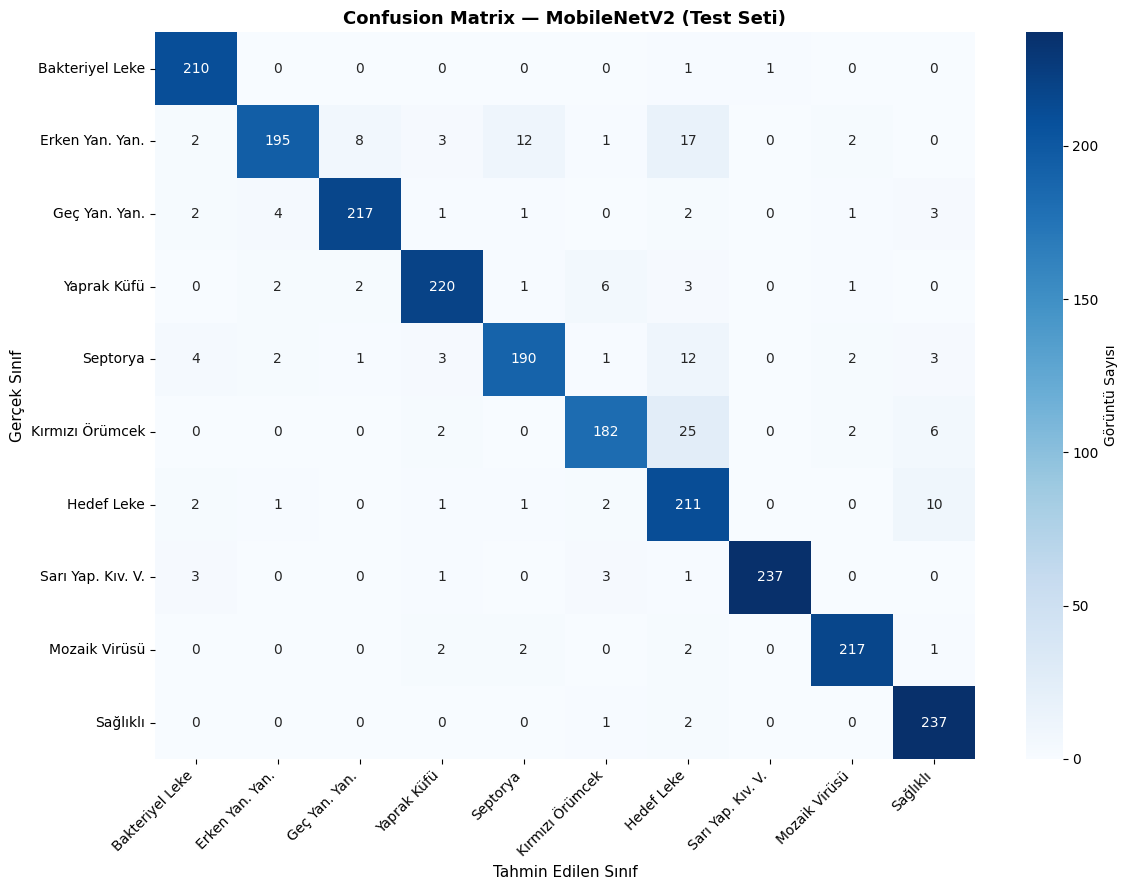


✅ Confusion matrix kaydedildi: confusion_matrix_mobilenetv2.png


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Test setinde tahminler yap
print("Test setinde tahminler yapılıyor...")
test_generator.reset()
predictions = best_model.predict(test_generator, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

# Sınıf isimlerini al
class_names = list(test_generator.class_indices.keys())
class_names_short = [c.replace("Tomato___", "").replace("_", " ") for c in class_names]

# Türkçe isimler (önceki sözlüğümüzden)
class_names_tr = {
    "Tomato___Bacterial_spot": "Bakteriyel Leke",
    "Tomato___Early_blight": "Erken Yan. Yan.",
    "Tomato___Late_blight": "Geç Yan. Yan.",
    "Tomato___Leaf_Mold": "Yaprak Küfü",
    "Tomato___Septoria_leaf_spot": "Septorya",
    "Tomato___Spider_mites Two-spotted_spider_mite": "Kırmızı Örümcek",
    "Tomato___Target_Spot": "Hedef Leke",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus": "Sarı Yap. Kıv. V.",
    "Tomato___Tomato_mosaic_virus": "Mozaik Virüsü",
    "Tomato___healthy": "Sağlıklı"
}
labels_tr = [class_names_tr[c] for c in class_names]

# Classification Report (Precision, Recall, F1)
print("\n" + "=" * 70)
print("📊 SINIF BAZLI PERFORMANS RAPORU — MobileNetV2")
print("=" * 70)
report = classification_report(y_true, y_pred, target_names=labels_tr, digits=4)
print(report)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_tr, yticklabels=labels_tr,
            cbar_kws={'label': 'Görüntü Sayısı'})
plt.title('Confusion Matrix — MobileNetV2 (Test Seti)', fontsize=13, fontweight='bold')
plt.ylabel('Gerçek Sınıf', fontsize=11)
plt.xlabel('Tahmin Edilen Sınıf', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix_mobilenetv2.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Confusion matrix kaydedildi: confusion_matrix_mobilenetv2.png")

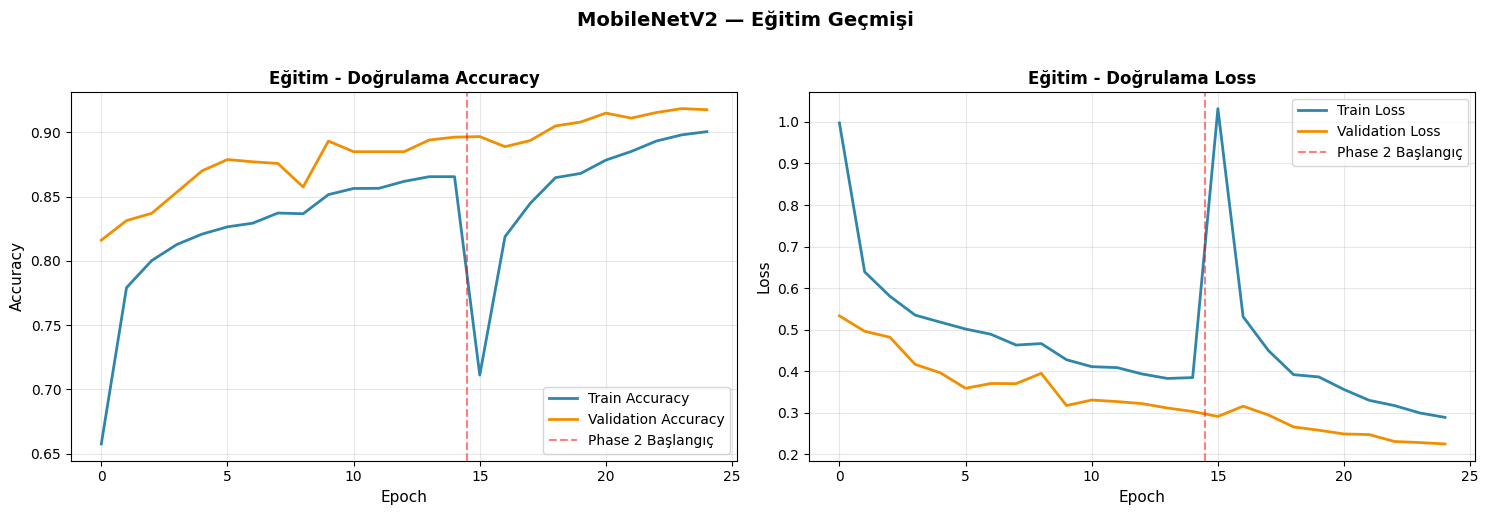

✅ Eğitim geçmişi kaydedildi: training_history_mobilenetv2.png


In [ ]:
import matplotlib.pyplot as plt

# Phase 1 ve Phase 2 verilerini birleştir
acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']
loss = history_phase1.history['loss'] + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']

# Phase ayrım çizgisi
phase1_end = len(history_phase1.history['accuracy'])

# Grafik çiz
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy grafiği
axes[0].plot(acc, label='Train Accuracy', color='#2E86AB', linewidth=2)
axes[0].plot(val_acc, label='Validation Accuracy', color='#F18F01', linewidth=2)
axes[0].axvline(x=phase1_end - 0.5, color='red', linestyle='--', alpha=0.5, label='Phase 2 Başlangıç')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Eğitim - Doğrulama Accuracy', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Loss grafiği
axes[1].plot(loss, label='Train Loss', color='#2E86AB', linewidth=2)
axes[1].plot(val_loss, label='Validation Loss', color='#F18F01', linewidth=2)
axes[1].axvline(x=phase1_end - 0.5, color='red', linestyle='--', alpha=0.5, label='Phase 2 Başlangıç')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].set_title('Eğitim - Doğrulama Loss', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

plt.suptitle('MobileNetV2 — Eğitim Geçmişi', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_history_mobilenetv2.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Eğitim geçmişi kaydedildi: training_history_mobilenetv2.png")

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import os

# Detaylı metrikler hesapla
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

# Model boyutu (MB)
model_size_mb = os.path.getsize('models/mobilenetv2_final.keras') / (1024 * 1024)

# Sonuçları sakla (sonra diğer modelleri de ekleyeceğiz)
results = {}
results['MobileNetV2'] = {
    'test_accuracy': test_accuracy,
    'test_loss': test_loss,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'model_size_mb': model_size_mb,
    'phase1_best_val_acc': max(history_phase1.history['val_accuracy']),
    'phase2_best_val_acc': max(history_phase2.history['val_accuracy']),
    'total_epochs': phase1_end + len(history_phase2.history['accuracy'])
}

# Özet yazdır
print("=" * 70)
print("📋 MOBILENETV2 ÖZET RAPORU")
print("=" * 70)
print(f"  Test Accuracy:     {test_accuracy*100:.2f}%")
print(f"  Test Loss:         {test_loss:.4f}")
print(f"  Precision:         {precision:.4f}")
print(f"  Recall:            {recall:.4f}")
print(f"  F1-Score:          {f1:.4f}")
print(f"  Model Boyutu:      {model_size_mb:.2f} MB")
print(f"  Toplam Epoch:      {results['MobileNetV2']['total_epochs']}")
print("=" * 70)
print("\n✅ MobileNetV2 sonuçları kaydedildi (results sözlüğüne)")
print("   Sırada: ResNet50 ve EfficientNetB0 eğitimi")

📋 MOBILENETV2 ÖZET RAPORU
  Test Accuracy:     92.40%
  Test Loss:         0.2237
  Precision:         0.9282
  Recall:            0.9240
  F1-Score:          0.9242
  Model Boyutu:      22.74 MB
  Toplam Epoch:      25

✅ MobileNetV2 sonuçları kaydedildi (results sözlüğüne)
   Sırada: ResNet50 ve EfficientNetB0 eğitimi


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive bağlandı")

Mounted at /content/drive
✅ Drive bağlandı


In [ ]:
import shutil
import os

# Drive'da proje klasörü oluştur
drive_proje_yolu = "/content/drive/MyDrive/Domates_Projesi"
os.makedirs(f"{drive_proje_yolu}/models", exist_ok=True)

# Modeli Drive'a kopyala
shutil.copy(
    "models/mobilenetv2_final.keras",
    f"{drive_proje_yolu}/models/mobilenetv2_final.keras"
)

# Boyutu göster
size_mb = os.path.getsize(f"{drive_proje_yolu}/models/mobilenetv2_final.keras") / (1024*1024)
print(f"✅ Model Drive'a kopyalandı: {size_mb:.2f} MB")
print(f"   Yol: {drive_proje_yolu}/models/mobilenetv2_final.keras")

✅ Model Drive'a kopyalandı: 22.74 MB
   Yol: /content/drive/MyDrive/Domates_Projesi/models/mobilenetv2_final.keras


In [ ]:
# Phase 1 modelini de kopyala (yedek olarak)
if os.path.exists("models/mobilenetv2_phase1.keras"):
    shutil.copy(
        "models/mobilenetv2_phase1.keras",
        f"{drive_proje_yolu}/models/mobilenetv2_phase1.keras"
    )
    print("✅ Phase 1 modeli de yedeklendi")

# Drive'daki dosyaları listele
print("\n📁 Drive'daki proje klasörü:")
for root, dirs, files in os.walk(drive_proje_yolu):
    level = root.replace(drive_proje_yolu, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}📁 {os.path.basename(root)}/")
    for file in files:
        size = os.path.getsize(os.path.join(root, file)) / (1024*1024)
        print(f"{indent}  📄 {file} ({size:.2f} MB)")

✅ Phase 1 modeli de yedeklendi

📁 Drive'daki proje klasörü:
📁 Domates_Projesi/
  📁 models/
    📄 mobilenetv2_final.keras (22.74 MB)
    📄 mobilenetv2_phase1.keras (11.07 MB)


In [ ]:
# Mevcut durumu kontrol et
import os

print("=" * 60)
print("🔍 DURUM KONTROLÜ")
print("=" * 60)

# Veri seti var mı?
print("\n📁 Veri seti:")
if os.path.exists("tomato_data/train"):
    classes = os.listdir("tomato_data/train")
    print(f"   ✅ tomato_data var ({len(classes)} sınıf)")
else:
    print("   ❌ tomato_data YOK (yeniden indirmemiz lazım)")

# MobileNetV2 modeli var mı?
print("\n🧠 Model dosyaları:")
if os.path.exists("models/mobilenetv2_final.keras"):
    size = os.path.getsize("models/mobilenetv2_final.keras") / (1024*1024)
    print(f"   ✅ mobilenetv2_final.keras ({size:.2f} MB)")
else:
    print("   ❌ Model YOK (Drive'dan kopyalamamız lazım)")

# Drive bağlı mı?
print("\n☁️ Google Drive:")
if os.path.exists("/content/drive"):
    print("   ✅ Drive bağlı")
    if os.path.exists("/content/drive/MyDrive/Domates_Projesi"):
        print("   ✅ Drive'da yedek var")
else:
    print("   ❌ Drive bağlı değil")

# Bellekte değişkenler var mı?
print("\n💾 Bellekteki değişkenler:")
try:
    test_var = train_generator
    print("   ✅ train_generator hazır")
except NameError:
    print("   ❌ train_generator YOK")

try:
    test_var = best_model
    print("   ✅ best_model hazır")
except NameError:
    print("   ❌ best_model YOK")

print("\n" + "=" * 60)

🔍 DURUM KONTROLÜ

📁 Veri seti:
   ❌ tomato_data YOK (yeniden indirmemiz lazım)

🧠 Model dosyaları:
   ❌ Model YOK (Drive'dan kopyalamamız lazım)

☁️ Google Drive:
   ❌ Drive bağlı değil

💾 Bellekteki değişkenler:
   ❌ train_generator YOK
   ❌ best_model YOK



In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive bağlandı")

Mounted at /content/drive
✅ Drive bağlandı


In [ ]:
import os
import shutil
import random
import numpy as np
import tensorflow as tf

# Sabit ayarlar
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 10

# Yollar
tomato_dir = "tomato_data"
tomato_train = f"{tomato_dir}/train"
tomato_valid = f"{tomato_dir}/valid"
tomato_test = f"{tomato_dir}/test"

# Drive yolu
drive_proje = "/content/drive/MyDrive/Domates_Projesi"

print("✅ Kütüphaneler yüklendi")
print(f"GPU sayısı: {len(tf.config.list_physical_devices('GPU'))}")

✅ Kütüphaneler yüklendi
GPU sayısı: 1


In [ ]:
# Kaggle kütüphanesi
!pip install -q kaggle

# kaggle.json'ı yükle
from google.colab import files
print("Lütfen kaggle.json dosyanızı seçin:")
files.upload()

Lütfen kaggle.json dosyanızı seçin:


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"YusufGude","key":"KGAT_5f82dbb077f076e0c4b17b8c37f1d4b5"}'}

In [ ]:
# Kaggle config
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("✅ Kaggle API hazır")

✅ Kaggle API hazır


In [ ]:
# Veri setini indir (~3 GB, 3-5 dk)
print("Veri seti indiriliyor...\n")
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

# Çıkar
print("\nÇıkarılıyor...")
!unzip -q new-plant-diseases-dataset.zip -d plant_data/

# Zip'i sil
!rm new-plant-diseases-dataset.zip

print("\n✅ İndirme ve çıkarma tamamlandı")

Veri seti indiriliyor...

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [00:23<00:00, 124MB/s]


Çıkarılıyor...

✅ İndirme ve çıkarma tamamlandı


In [ ]:
import shutil

# Çift kopya ve test klasörünü sil
for unwanted in ["plant_data/new plant diseases dataset(augmented)", "plant_data/test"]:
    if os.path.exists(unwanted):
        shutil.rmtree(unwanted)
        print(f"✓ Silindi: {unwanted}")

# Orijinal yollar
original_train = "plant_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
original_valid = "plant_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

# Domates sınıflarını bul
all_classes = sorted(os.listdir(original_train))
tomato_classes = [c for c in all_classes if c.startswith("Tomato")]

# Hedef klasörler
os.makedirs(tomato_train, exist_ok=True)
os.makedirs(tomato_valid, exist_ok=True)

print("\nDomates klasörleri taşınıyor...")
for cls in tomato_classes:
    # Train
    src = os.path.join(original_train, cls)
    dst = os.path.join(tomato_train, cls)
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.move(src, dst)
    # Valid
    src = os.path.join(original_valid, cls)
    dst = os.path.join(tomato_valid, cls)
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.move(src, dst)

# Orijinal veriyi sil
shutil.rmtree("plant_data")
print("✅ Domates filtreleme tamamlandı")
print(f"   Sınıf sayısı: {len(tomato_classes)}")

✓ Silindi: plant_data/new plant diseases dataset(augmented)
✓ Silindi: plant_data/test

Domates klasörleri taşınıyor...
✅ Domates filtreleme tamamlandı
   Sınıf sayısı: 10


In [ ]:
random.seed(42)
os.makedirs(tomato_test, exist_ok=True)
classes = sorted(os.listdir(tomato_valid))

print("Valid → Valid + Test ayrımı...")
for cls in classes:
    valid_dir = os.path.join(tomato_valid, cls)
    test_dir = os.path.join(tomato_test, cls)
    os.makedirs(test_dir, exist_ok=True)

    images = os.listdir(valid_dir)
    random.shuffle(images)
    test_count = len(images) // 2
    for img in images[:test_count]:
        shutil.move(os.path.join(valid_dir, img), os.path.join(test_dir, img))

# Özet
total = 0
for split, path in [("Train", tomato_train), ("Valid", tomato_valid), ("Test", tomato_test)]:
    count = sum(len(os.listdir(os.path.join(path, c))) for c in classes)
    total += count
    print(f"  {split}: {count} görüntü")
print(f"  TOPLAM: {total} görüntü ✅")

Valid → Valid + Test ayrımı...
  Train: 18345 görüntü
  Valid: 2295 görüntü
  Test: 2290 görüntü
  TOPLAM: 22930 görüntü ✅


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    tomato_train, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True, seed=42
)
valid_generator = valid_datagen.flow_from_directory(
    tomato_valid, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
test_generator = test_datagen.flow_from_directory(
    tomato_test, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

print("\n✅ DataGenerator'lar hazır")

Found 18345 images belonging to 10 classes.
Found 2295 images belonging to 10 classes.
Found 2290 images belonging to 10 classes.

✅ DataGenerator'lar hazır


In [ ]:
from tensorflow.keras.models import load_model

# Modeli kaydetmek için klasör
os.makedirs("models", exist_ok=True)

# Drive'dan kopyala
shutil.copy(
    f"{drive_proje}/models/mobilenetv2_final.keras",
    "models/mobilenetv2_final.keras"
)

# Yükle
mobilenet_model = load_model("models/mobilenetv2_final.keras")
print("✅ MobileNetV2 modeli Drive'dan geri yüklendi")
print(f"   Dosya boyutu: {os.path.getsize('models/mobilenetv2_final.keras')/(1024*1024):.2f} MB")

# Hızlı test (modelin çalıştığını doğrula)
test_generator.reset()
loss, acc = mobilenet_model.evaluate(test_generator, verbose=0)
print(f"\n🎯 MobileNetV2 Test Accuracy: {acc*100:.2f}% (Önceki: %92.40)")

✅ MobileNetV2 modeli Drive'dan geri yüklendi
   Dosya boyutu: 22.74 MB

🎯 MobileNetV2 Test Accuracy: 92.40% (Önceki: %92.40)


In [ ]:
import shutil
import os
import time

# Drive'da veri klasörü
drive_data_path = "/content/drive/MyDrive/Domates_Projesi/data"

# Eğer Drive'da veri zaten varsa, atla
if os.path.exists(drive_data_path):
    print("✅ Drive'da veri zaten var, atlıyorum")
else:
    print("📦 Veri seti Drive'a kopyalanıyor (~5 dk sürer)...\n")
    start = time.time()

    # tomato_data klasörünü Drive'a kopyala
    shutil.copytree("tomato_data", drive_data_path)

    elapsed = time.time() - start
    print(f"\n✅ Yedekleme tamamlandı! Süre: {elapsed/60:.1f} dakika")

# Doğrulama
print("\n📁 Drive'daki veri yapısı:")
for split in ["train", "valid", "test"]:
    split_path = f"{drive_data_path}/{split}"
    if os.path.exists(split_path):
        total = sum(len(os.listdir(os.path.join(split_path, c)))
                   for c in os.listdir(split_path))
        print(f"   ✅ {split}: {total} görüntü")

📦 Veri seti Drive'a kopyalanıyor (~5 dk sürer)...


✅ Yedekleme tamamlandı! Süre: 5.5 dakika

📁 Drive'daki veri yapısı:
   ✅ train: 18345 görüntü
   ✅ valid: 2295 görüntü
   ✅ test: 2290 görüntü


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os
drive_path = "/content/drive/MyDrive/Domates_Projesi"

# Veriyi Drive'dan kopyala
if not os.path.exists("tomato_data"):
    shutil.copytree(f"{drive_path}/data", "tomato_data")
    print("✅ Veri seti Drive'dan kopyalandı")

# Modelleri Drive'dan kopyala
os.makedirs("models", exist_ok=True)
for model_file in os.listdir(f"{drive_path}/models"):
    src = f"{drive_path}/models/{model_file}"
    dst = f"models/{model_file}"
    if not os.path.exists(dst):
        shutil.copy(src, dst)
        print(f"✅ {model_file} kopyalandı")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ mobilenetv2_phase1.keras kopyalandı


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

print("🔨 ResNet50 modeli kuruluyor...")

# 1. Hazır ResNet50'yi yükle (ImageNet ağırlıkları)
resnet_base = ResNet50(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# 2. Base modeli dondur
resnet_base.trainable = False

# 3. Üstüne kendi katmanlarımızı ekle (MobileNetV2 ile aynı yapı)
x = resnet_base.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

# 4. Modeli oluştur
resnet_model = Model(inputs=resnet_base.input, outputs=predictions)

# 5. Compile et
resnet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Bilgi
print(f"\n✅ ResNet50 modeli kuruldu!")
print(f"\n📊 Model İstatistikleri:")
print(f"   Toplam parametre: {resnet_model.count_params():,}")

trainable = sum([tf.size(w).numpy() for w in resnet_model.trainable_weights])
print(f"   Eğitilebilir:     {trainable:,}")
print(f"   Donmuş (frozen):  {resnet_model.count_params() - trainable:,}")
print(f"   Toplam katman:    {len(resnet_base.layers)}")

print(f"\n🎯 Karşılaştırma:")
print(f"   MobileNetV2: ~2.4M parametre, 154 katman, 22.74 MB")
print(f"   ResNet50:    ~24M parametre, 175 katman, ~98 MB (10x daha büyük)")

🔨 ResNet50 modeli kuruluyor...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

✅ ResNet50 modeli kuruldu!

📊 Model İstatistikleri:
   Toplam parametre: 23,851,274
   Eğitilebilir:     263,562
   Donmuş (frozen):  23,587,712
   Toplam katman:    175

🎯 Karşılaştırma:
   MobileNetV2: ~2.4M parametre, 154 katman, 22.74 MB
   ResNet50:    ~24M parametre, 175 katman, ~98 MB (10x daha büyük)


In [ ]:
import gc

# Bozuk modeli ve geçmişi sil
try:
    del resnet_model
    print("✓ Bozuk resnet_model silindi")
except:
    print("- resnet_model zaten yok")

try:
    del resnet_history_p1
    print("✓ Bozuk eğitim geçmişi silindi")
except:
    print("- resnet_history_p1 zaten yok")

try:
    del resnet_base
    print("✓ Bozuk resnet_base silindi")
except:
    print("- resnet_base zaten yok")

# Bellek temizliği
gc.collect()
import tensorflow as tf
tf.keras.backend.clear_session()

print("\n✅ Bellek temizlendi, yeni model için hazır")

✓ Bozuk resnet_model silindi
✓ Bozuk eğitim geçmişi silindi
✓ Bozuk resnet_base silindi

✅ Bellek temizlendi, yeni model için hazır


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

# ResNet50'ye ÖZEL preprocessing
train_datagen_resnet = ImageDataGenerator(
    preprocessing_function=resnet_preprocess,  # ← KRİTİK
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)

valid_datagen_resnet = ImageDataGenerator(preprocessing_function=resnet_preprocess)
test_datagen_resnet = ImageDataGenerator(preprocessing_function=resnet_preprocess)

# YENİ generator'lar
train_generator_resnet = train_datagen_resnet.flow_from_directory(
    "tomato_data/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

valid_generator_resnet = valid_datagen_resnet.flow_from_directory(
    "tomato_data/valid",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator_resnet = test_datagen_resnet.flow_from_directory(
    "tomato_data/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\n✅ ResNet50 generator'ları hazır (doğru preprocessing ile)")

Found 18345 images belonging to 10 classes.
Found 2295 images belonging to 10 classes.
Found 2290 images belonging to 10 classes.

✅ ResNet50 generator'ları hazır (doğru preprocessing ile)


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

print("🔨 ResNet50 modeli kuruluyor...")

resnet_base = ResNet50(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
resnet_base.trainable = False

x = resnet_base.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

resnet_model = Model(inputs=resnet_base.input, outputs=predictions)

resnet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"✅ ResNet50 hazır")
print(f"   Toplam parametre: {resnet_model.count_params():,}")
print(f"   Toplam katman: {len(resnet_base.layers)}")

🔨 ResNet50 modeli kuruluyor...
✅ ResNet50 hazır
   Toplam parametre: 23,851,274
   Toplam katman: 175


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import time

callbacks_resnet_p1 = [
    ModelCheckpoint(
        'models/resnet50_phase1.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1
    )
]

print("=" * 70)
print("🚀 ResNet50 — AŞAMA 1 (DOĞRU PREPROCESSING)")
print("=" * 70)
print("Beklenen süre: ~50-60 dakika")
print("⚠️  İlk epoch'ta accuracy %70+ olmalı!\n")

start = time.time()

resnet_history_p1 = resnet_model.fit(
    train_generator_resnet,                # ← YENİ generator (ÖNEMLİ!)
    epochs=15,
    validation_data=valid_generator_resnet, # ← YENİ generator (ÖNEMLİ!)
    callbacks=callbacks_resnet_p1,
    verbose=1
)

elapsed = time.time() - start
print(f"\n✅ Phase 1 tamamlandı! Süre: {elapsed/60:.1f} dakika")
print(f"   En iyi val_accuracy: {max(resnet_history_p1.history['val_accuracy']):.4f}")

🚀 ResNet50 — AŞAMA 1 (DOĞRU PREPROCESSING)
Beklenen süre: ~50-60 dakika
⚠️  İlk epoch'ta accuracy %70+ olmalı!

Epoch 1/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.6445 - loss: 1.0571
Epoch 1: val_accuracy improved from None to 0.90327, saving model to models/resnet50_phase1.keras

Epoch 1: finished saving model to models/resnet50_phase1.keras
574/574 ━━━━━━━━━━━━━━━━━━━━ 294s 488ms/step - accuracy: 0.7596 - loss: 0.7005 - val_accuracy: 0.9033 - val_loss: 0.2831 - learning_rate: 0.0010
Epoch 2/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.8666 - loss: 0.3943
Epoch 2: val_accuracy improved from 0.90327 to 0.92070, saving model to models/resnet50_phase1.keras

Epoch 2: finished saving model to models/resnet50_phase1.keras
574/574 ━━━━━━━━━━━━━━━━━━━━ 262s 457ms/step - accuracy: 0.8700 - loss: 0.3806 - val_accuracy: 0.9207 - val_loss: 0.2306 - learning_rate: 0.0010
Epoch 3/15
574/574 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.8849 - loss: 0.3319
Epoch 3

In [3]:
# ============================================================
# ⭐ HAZIRLIK HÜCRESİ — Sıfırdan eski duruma dönüş
# ============================================================

# 1. Drive'ı bağla
from google.colab import drive
drive.mount('/content/drive')

import os
import shutil
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 2. Sabit ayarlar
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 10
drive_proje = "/content/drive/MyDrive/Domates_Projesi"

# 3. Veriyi Drive'dan kopyala
if not os.path.exists("tomato_data"):
    print("📦 Veri seti Drive'dan kopyalanıyor...")
    shutil.copytree(f"{drive_proje}/data", "tomato_data")
    print("   ✅ Tamamlandı")
else:
    print("✅ Veri seti zaten yerinde")

# 4. Modelleri Drive'dan kopyala
os.makedirs("models", exist_ok=True)
print("\n🧠 Modeller kopyalanıyor...")
for model_file in os.listdir(f"{drive_proje}/models"):
    src = f"{drive_proje}/models/{model_file}"
    dst = f"models/{model_file}"
    if not os.path.exists(dst):
        shutil.copy(src, dst)
        size_mb = os.path.getsize(dst) / (1024*1024)
        print(f"   ✅ {model_file} ({size_mb:.1f} MB)")

# 5. MobileNetV2 generator'ları (rescale=1./255)
print("\n🔧 MobileNetV2 generator'ları kuruluyor...")
train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=20,
    width_shift_range=0.1, height_shift_range=0.1,
    horizontal_flip=True, zoom_range=0.1, fill_mode='nearest'
)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "tomato_data/train", target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True, seed=42
)
valid_generator = valid_datagen.flow_from_directory(
    "tomato_data/valid", target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
test_generator = test_datagen.flow_from_directory(
    "tomato_data/test", target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

# 6. GPU kontrolü
gpu_count = len(tf.config.list_physical_devices('GPU'))
print(f"\n🖥️  GPU sayısı: {gpu_count}")

print("\n" + "="*50)
print("✅ HAZIRLIK TAMAMLANDI")
print("="*50)

Mounted at /content/drive
📦 Veri seti Drive'dan kopyalanıyor...
   ✅ Tamamlandı

🧠 Modeller kopyalanıyor...
   ✅ mobilenetv2_final.keras (22.7 MB)
   ✅ mobilenetv2_phase1.keras (11.1 MB)

🔧 MobileNetV2 generator'ları kuruluyor...
Found 18345 images belonging to 10 classes.
Found 2295 images belonging to 10 classes.
Found 2290 images belonging to 10 classes.

🖥️  GPU sayısı: 1

✅ HAZIRLIK TAMAMLANDI


In [4]:
# ============================================================
# 🗑️ SİLİNECEK - Yeniden hazırlık (proje teslim edilirken kaldırılacak)
# Sebep: Bu sadece kurtarma sürecinde tekrar generator kuruluyor
# Final notebook'ta tek bir generator hücresi olacak
# ============================================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

# ResNet50'ye özel preprocessing
train_datagen_resnet = ImageDataGenerator(
    preprocessing_function=resnet_preprocess,
    rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,
    horizontal_flip=True, zoom_range=0.1, fill_mode='nearest'
)
valid_datagen_resnet = ImageDataGenerator(preprocessing_function=resnet_preprocess)
test_datagen_resnet = ImageDataGenerator(preprocessing_function=resnet_preprocess)

train_generator_resnet = train_datagen_resnet.flow_from_directory(
    "tomato_data/train", target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True, seed=42
)
valid_generator_resnet = valid_datagen_resnet.flow_from_directory(
    "tomato_data/valid", target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
test_generator_resnet = test_datagen_resnet.flow_from_directory(
    "tomato_data/test", target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

print("\n✅ ResNet50 generator'ları hazır (doğru preprocessing)")

Found 18345 images belonging to 10 classes.
Found 2295 images belonging to 10 classes.
Found 2290 images belonging to 10 classes.

✅ ResNet50 generator'ları hazır (doğru preprocessing)


In [5]:
# ============================================================
# ✅ KALACAK - ResNet50 Modeli Kurulumu
# ============================================================

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

print("🔨 ResNet50 modeli kuruluyor...")

# 1. Hazır ResNet50'yi yükle (ImageNet ağırlıkları)
resnet_base = ResNet50(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# 2. Base modeli dondur
resnet_base.trainable = False

# 3. Üstüne kendi katmanlarımızı ekle
x = resnet_base.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

# 4. Modeli oluştur
resnet_model = Model(inputs=resnet_base.input, outputs=predictions)

# 5. Compile
resnet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"✅ ResNet50 hazır")
print(f"   Toplam parametre: {resnet_model.count_params():,}")
print(f"   Toplam katman: {len(resnet_base.layers)}")

🔨 ResNet50 modeli kuruluyor...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
✅ ResNet50 hazır
   Toplam parametre: 23,851,274
   Toplam katman: 175


In [6]:
# ============================================================
# ✅ KALACAK - ResNet50 Phase 1 Eğitimi
# ============================================================

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import time

callbacks_resnet_p1 = [
    ModelCheckpoint(
        'models/resnet50_phase1.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=4,
        restore_best_weights=True,
        verbose=1
    )
]

print("=" * 70)
print("🚀 ResNet50 — AŞAMA 1: Feature Extraction")
print("=" * 70)
print("Süreç: ResNet50 base donmuş, sadece üst katmanlar eğitiliyor.")
print("Beklenen süre: ~45 dakika (10 epoch)")
print("⚠️  İlk epoch'ta accuracy %70+ olmalı!\n")

start = time.time()

resnet_history_p1 = resnet_model.fit(
    train_generator_resnet,                # ← ResNet50 generator
    epochs=10,                             # ← 10 epoch (15 yerine)
    validation_data=valid_generator_resnet,
    callbacks=callbacks_resnet_p1,
    verbose=1
)

elapsed = time.time() - start
print(f"\n✅ Phase 1 tamamlandı! Süre: {elapsed/60:.1f} dakika")
print(f"   En iyi val_accuracy: {max(resnet_history_p1.history['val_accuracy']):.4f}")

🚀 ResNet50 — AŞAMA 1: Feature Extraction
Süreç: ResNet50 base donmuş, sadece üst katmanlar eğitiliyor.
Beklenen süre: ~45 dakika (10 epoch)
⚠️  İlk epoch'ta accuracy %70+ olmalı!

Epoch 1/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.6214 - loss: 1.1335
Epoch 1: val_accuracy improved from None to 0.89020, saving model to models/resnet50_phase1.keras

Epoch 1: finished saving model to models/resnet50_phase1.keras
574/574 ━━━━━━━━━━━━━━━━━━━━ 284s 465ms/step - accuracy: 0.7467 - loss: 0.7448 - val_accuracy: 0.8902 - val_loss: 0.3278 - learning_rate: 0.0010
Epoch 2/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.8589 - loss: 0.4175
Epoch 2: val_accuracy improved from 0.89020 to 0.90414, saving model to models/resnet50_phase1.keras

Epoch 2: finished saving model to models/resnet50_phase1.keras
574/574 ━━━━━━━━━━━━━━━━━━━━ 247s 429ms/step - accuracy: 0.8627 - loss: 0.4021 - val_accuracy: 0.9041 - val_loss: 0.2653 - learning_rate: 0.0010
Epoch 3/10
574/574 ━━━━━━━━

In [7]:
# ============================================================
# 🗑️ SİLİNECEK - ResNet50 Phase 1 Drive yedekleme
# Sebep: Sadece çalışma sürecinde lazım, projede gerekmez
# ============================================================

import shutil
import os

shutil.copy(
    "models/resnet50_phase1.keras",
    f"{drive_proje}/models/resnet50_phase1.keras"
)
size_mb = os.path.getsize(f"{drive_proje}/models/resnet50_phase1.keras") / (1024*1024)
print(f"✅ ResNet50 Phase 1 Drive'a yedeklendi! ({size_mb:.2f} MB)")
print("   Artık güvende, GPU kesilse bile kaybolmaz")

✅ ResNet50 Phase 1 Drive'a yedeklendi! (93.63 MB)
   Artık güvende, GPU kesilse bile kaybolmaz


In [8]:
# ============================================================
# ✅ KALACAK - ResNet50 Phase 2 Hazırlık (Fine-tuning)
# ============================================================

from tensorflow.keras.optimizers import Adam

# Base modelin son katmanlarını eğitilebilir yap
resnet_base.trainable = True

total_layers = len(resnet_base.layers)
print(f"ResNet50 toplam katman: {total_layers}")

# Son 30 katmanı aç, geri kalanı dondur
fine_tune_at = total_layers - 30

for layer in resnet_base.layers[:fine_tune_at]:
    layer.trainable = False

# DİKKAT: Çok düşük learning rate (1e-5)
resnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable_params = sum([tf.size(w).numpy() for w in resnet_model.trainable_weights])
print(f"\n✅ Fine-tuning için hazır")
print(f"   Eğitilebilir parametre: {trainable_params:,}")
print(f"   Donmuş katman: {fine_tune_at}")
print(f"   Açık katman: 30")

ResNet50 toplam katman: 175

✅ Fine-tuning için hazır
   Eğitilebilir parametre: 14,713,738
   Donmuş katman: 145
   Açık katman: 30


In [9]:
# ============================================================
# ✅ KALACAK - ResNet50 Phase 2 Eğitimi
# ============================================================

import time

callbacks_resnet_p2 = [
    ModelCheckpoint(
        'models/resnet50_final.keras',  # YENİ İSİM (final model)
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-8, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1)
]

print("=" * 70)
print("🚀 ResNet50 — AŞAMA 2: Fine-Tuning")
print("=" * 70)
print("Süreç: Son 30 katman açıldı, düşük LR ile ince ayar")
print("Beklenen süre: ~50 dakika (10 epoch)")
print(f"Phase 1 sonu: %94.86 → hedef Phase 2: %96+\n")

start = time.time()

resnet_history_p2 = resnet_model.fit(
    train_generator_resnet,
    epochs=10,
    validation_data=valid_generator_resnet,
    callbacks=callbacks_resnet_p2,
    verbose=1
)

elapsed = time.time() - start
print(f"\n✅ Phase 2 tamamlandı! Süre: {elapsed/60:.1f} dakika")
print(f"   En iyi val_accuracy: {max(resnet_history_p2.history['val_accuracy']):.4f}")
print(f"\n📊 İyileşme:")
print(f"   Phase 1: %94.86")
print(f"   Phase 2: %{max(resnet_history_p2.history['val_accuracy'])*100:.2f}")

🚀 ResNet50 — AŞAMA 2: Fine-Tuning
Süreç: Son 30 katman açıldı, düşük LR ile ince ayar
Beklenen süre: ~50 dakika (10 epoch)
Phase 1 sonu: %94.86 → hedef Phase 2: %96+

Epoch 1/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.8365 - loss: 0.5409
Epoch 1: val_accuracy improved from None to 0.94030, saving model to models/resnet50_final.keras

Epoch 1: finished saving model to models/resnet50_final.keras
574/574 ━━━━━━━━━━━━━━━━━━━━ 303s 477ms/step - accuracy: 0.8874 - loss: 0.3519 - val_accuracy: 0.9403 - val_loss: 0.1591 - learning_rate: 1.0000e-05
Epoch 2/10
574/574 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.9333 - loss: 0.1971
Epoch 2: val_accuracy improved from 0.94030 to 0.95294, saving model to models/resnet50_final.keras

Epoch 2: finished saving model to models/resnet50_final.keras
574/574 ━━━━━━━━━━━━━━━━━━━━ 254s 442ms/step - accuracy: 0.9386 - loss: 0.1793 - val_accuracy: 0.9529 - val_loss: 0.1222 - learning_rate: 1.0000e-05
Epoch 3/10
574/574 ━━━━━━━━━━━━━━━━━

In [10]:
# ============================================================
# 🗑️ SİLİNECEK - ResNet50 final Drive yedekleme
# ============================================================

import shutil
import os

# Final modeli Drive'a kopyala
shutil.copy(
    "models/resnet50_final.keras",
    f"{drive_proje}/models/resnet50_final.keras"
)
size_mb = os.path.getsize(f"{drive_proje}/models/resnet50_final.keras") / (1024*1024)
print(f"✅ ResNet50 Final modeli Drive'a yedeklendi! ({size_mb:.2f} MB)")

# Drive'daki tüm modelleri listele
print("\n📁 Drive'daki tüm modeller:")
for f in sorted(os.listdir(f"{drive_proje}/models")):
    size = os.path.getsize(f"{drive_proje}/models/{f}") / (1024*1024)
    print(f"   📄 {f} ({size:.1f} MB)")

✅ ResNet50 Final modeli Drive'a yedeklendi! (203.90 MB)

📁 Drive'daki tüm modeller:
   📄 mobilenetv2_final.keras (22.7 MB)
   📄 mobilenetv2_phase1.keras (11.1 MB)
   📄 resnet50_final.keras (203.9 MB)
   📄 resnet50_phase1.keras (93.6 MB)


In [11]:
# ============================================================
# ✅ KALACAK - ResNet50 Test Değerlendirmesi
# ============================================================

from tensorflow.keras.models import load_model
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# En iyi modeli yükle
print("ResNet50 final modeli yükleniyor...")
resnet_best = load_model('models/resnet50_final.keras')

# Test seti üzerinde değerlendir
print("\nTest seti değerlendiriliyor...")
test_generator_resnet.reset()
test_loss_resnet, test_acc_resnet = resnet_best.evaluate(test_generator_resnet, verbose=1)

# Tahminler
test_generator_resnet.reset()
predictions_resnet = resnet_best.predict(test_generator_resnet, verbose=1)
y_pred_resnet = np.argmax(predictions_resnet, axis=1)
y_true_resnet = test_generator_resnet.classes

# Metrikleri hesapla
precision_resnet = precision_score(y_true_resnet, y_pred_resnet, average='weighted')
recall_resnet = recall_score(y_true_resnet, y_pred_resnet, average='weighted')
f1_resnet = f1_score(y_true_resnet, y_pred_resnet, average='weighted')
model_size_resnet = os.path.getsize('models/resnet50_final.keras') / (1024 * 1024)

# Sonuçları yazdır
print("\n" + "=" * 70)
print("📋 RESNET50 ÖZET RAPORU")
print("=" * 70)
print(f"  Test Accuracy:     {test_acc_resnet*100:.2f}%")
print(f"  Test Loss:         {test_loss_resnet:.4f}")
print(f"  Precision:         {precision_resnet:.4f}")
print(f"  Recall:            {recall_resnet:.4f}")
print(f"  F1-Score:          {f1_resnet:.4f}")
print(f"  Model Boyutu:      {model_size_resnet:.2f} MB")
print("=" * 70)

# Karşılaştırma
print("\n📊 KARŞILAŞTIRMA — MobileNetV2 vs ResNet50:")
print(f"   MobileNetV2: Test Acc %92.40, F1 0.9242, Boyut 22.74 MB")
print(f"   ResNet50:    Test Acc {test_acc_resnet*100:.2f}%, F1 {f1_resnet:.4f}, Boyut {model_size_resnet:.2f} MB")

ResNet50 final modeli yükleniyor...

Test seti değerlendiriliyor...
72/72 ━━━━━━━━━━━━━━━━━━━━ 18s 149ms/step - accuracy: 0.9865 - loss: 0.0559
72/72 ━━━━━━━━━━━━━━━━━━━━ 15s 150ms/step

📋 RESNET50 ÖZET RAPORU
  Test Accuracy:     98.65%
  Test Loss:         0.0559
  Precision:         0.9866
  Recall:            0.9865
  F1-Score:          0.9865
  Model Boyutu:      203.90 MB

📊 KARŞILAŞTIRMA — MobileNetV2 vs ResNet50:
   MobileNetV2: Test Acc %92.40, F1 0.9242, Boyut 22.74 MB
   ResNet50:    Test Acc 98.65%, F1 0.9865, Boyut 203.90 MB


In [12]:
# ============================================================
# 🗑️ SİLİNECEK - Sonuçları Drive'a not olarak kaydet
# ============================================================

with open(f"{drive_proje}/sonuclar.txt", "w") as f:
    f.write("=" * 60 + "\n")
    f.write("DOMATES PROJESİ - SONUÇLAR\n")
    f.write("=" * 60 + "\n\n")

    f.write("📋 MobileNetV2:\n")
    f.write(f"   Test Accuracy: %92.40\n")
    f.write(f"   F1-Score:      0.9242\n")
    f.write(f"   Boyut:         22.74 MB\n\n")

    f.write("📋 ResNet50:\n")
    f.write(f"   Test Accuracy: %{test_acc_resnet*100:.2f}\n")
    f.write(f"   F1-Score:      {f1_resnet:.4f}\n")
    f.write(f"   Boyut:         {model_size_resnet:.2f} MB\n\n")

    f.write("⏳ EfficientNetB0: Henüz yapılmadı (yarın yapılacak)\n")

print("✅ Sonuçlar Drive'a kaydedildi: Domates_Projesi/sonuclar.txt")
print("   Yarın bu dosyaya bakarak nerede kaldığımı hatırlayabilirim")

✅ Sonuçlar Drive'a kaydedildi: Domates_Projesi/sonuclar.txt
   Yarın bu dosyaya bakarak nerede kaldığımı hatırlayabilirim
